<a href="https://colab.research.google.com/github/RASIUT/ML/blob/main/Dimensionality_Reduction/Linear_Discriminant_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Importing Libraries

In [20]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
%matplotlib inline

##Importing Datasets

In [21]:
df = pd.read_csv('Wine.csv')
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

##Splitting dataset into training and test split

In [22]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

##Feature Scaling

In [23]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

##Applying LDA

In [24]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

lda = LDA(n_components = 2)

X_train = lda.fit_transform(X_train, y_train)
X_test = lda.transform(X_test)

##Training the Logistic Regression model on train set

In [25]:
from sklearn.linear_model import LogisticRegression

classifier = LogisticRegression(random_state = 0)
classifier.fit(X_train, y_train)

LogisticRegression(random_state=0)

##Confusion matrix and accuracy score

In [26]:
from sklearn.metrics import confusion_matrix, accuracy_score

y_pred = classifier.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
print(cm)

accuracy_score(y_test, y_pred)

[[14  0  0]
 [ 0 16  0]
 [ 0  0  6]]


1.0

##Visualizing the results

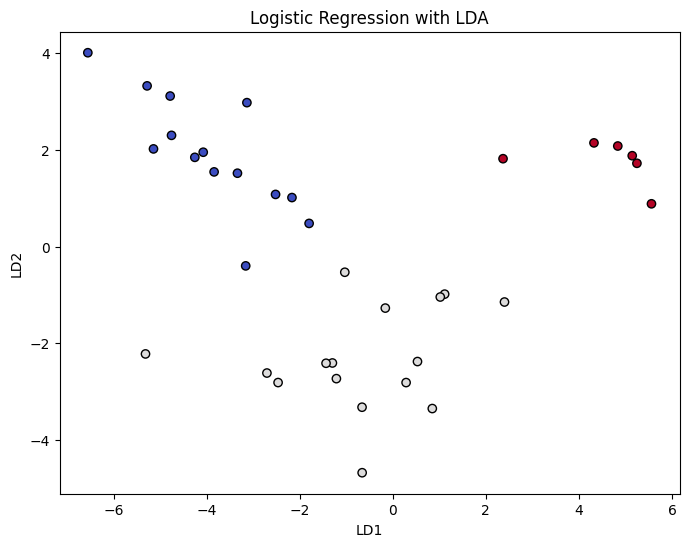

In [27]:
plt.figure(figsize = (8, 6))
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_pred, cmap='coolwarm', edgecolors='k')
plt.xlabel('LD1')
plt.ylabel('LD2')
plt.title('Logistic Regression with LDA')
plt.show()